# K-Nearest Neighbors (KNN) from Scratch 📍

In this notebook, we implement **K-Nearest Neighbors (KNN)**, a simple yet powerful instance-based learning algorithm.

## 📖 Theoretical Background

KNN is a **non-parametric** and **lazy learning** algorithm. It doesn't learn a discriminative function from the training data but instead memorizes the entire training dataset.

### 1. The Algorithm
For a given test point $x$:
1. Calculate the distance between $x$ and all points in the training set.
2. Select the $K$ points with the smallest distances.
3. Perform a majority vote (classification) or average (regression) among these $K$ points.

### 2. Distance Metrics
The choice of distance metric is crucial. Two common ones are:
- **Euclidean Distance**:
  $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
- **Manhattan Distance**:
  $$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

class KNN:
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        if distance_metric == 'euclidean':
            self.dist_fn = euclidean_distance
        else:
            self.dist_fn = manhattan_distance

    def fit(self, X, y):
        # KNN just stores the training data
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # 1. Compute distances
        distances = [self.dist_fn(x, x_train) for x_train in self.X_train]
        
        # 2. Get k nearest samples, labels
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # 3. Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

## 🧪 Data Generation and Training

In [3]:
# Generate data with 3 clusters
X, y = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=1.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Instantiate and fit model
clf = KNN(k=5)
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"KNN Classification Accuracy: {accuracy * 100:.2f}%")

KNN Classification Accuracy: 100.00%


## 📊 Visualization

We will visualize the decision regions by predicting on a grid.

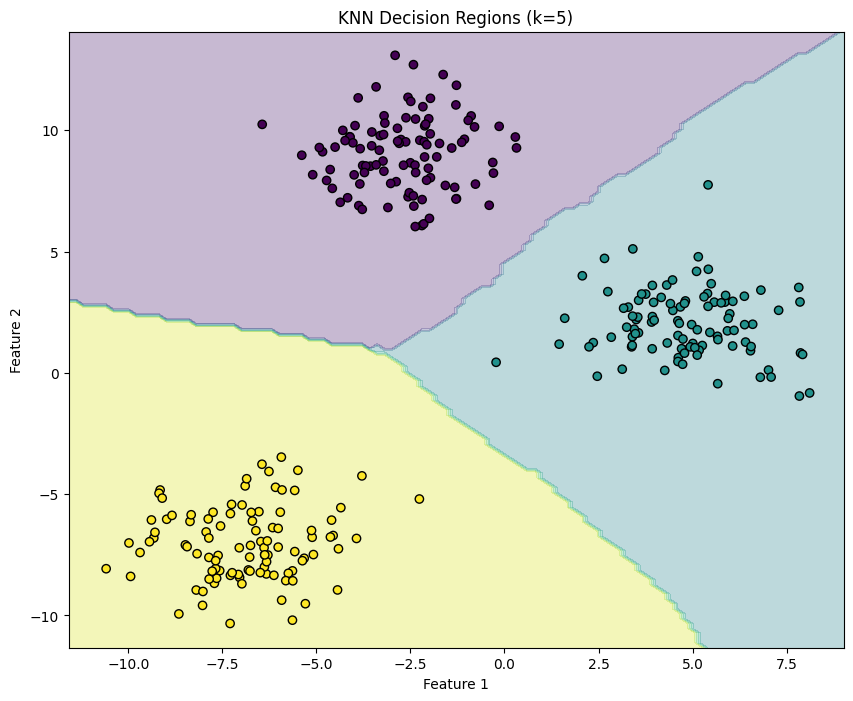

In [4]:
plt.figure(figsize=(10, 8))

# Create mesh grid
h = 0.2 # step size
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contour
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title(f"KNN Decision Regions (k={clf.k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 📊 Additional Visualizations

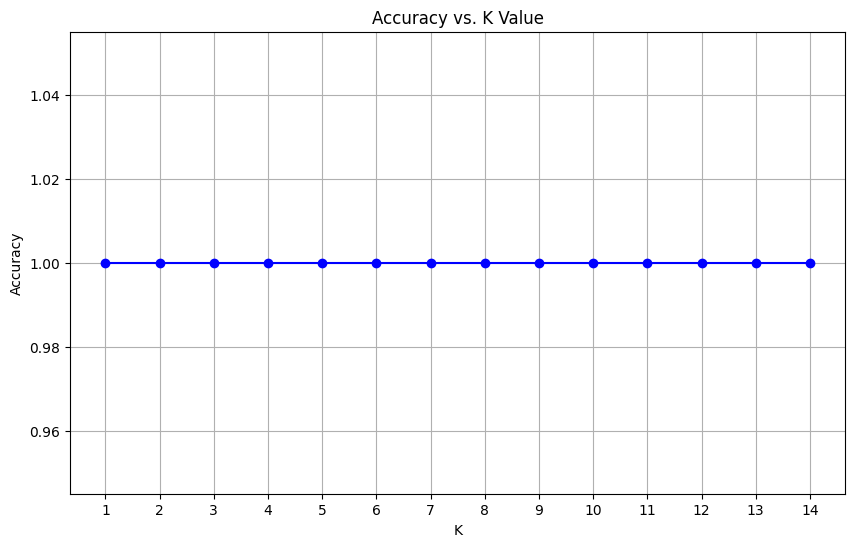

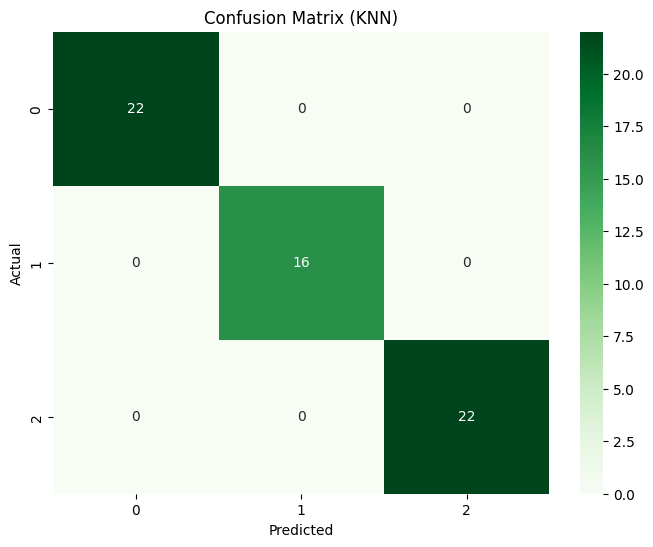

In [5]:

# 1. Elbow Method for Optimal K
k_values = range(1, 15)
accuracies = []

for k in k_values:
    temp_knn = KNN(k=k)
    temp_knn.fit(X_train, y_train)
    temp_preds = temp_knn.predict(X_test)
    acc = np.sum(temp_preds == y_test) / len(y_test)
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
